# Fig. 5: model and empirical tests of multiplexed iSPN roles

This notebook reads the outputs from Notebook 07 and creates the final twin-y-axis boxplot figure.

- Gray boxes: CBGT model, left y-axis.
- Blue boxes: pooled IBL+Steinmetz recordings, right y-axis.
- Panels A and B: bootstrap distributions.
- Panel C: raw trial-level decision-time distributions.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import matplotlib.pyplot as plt

from spn_figures.config import DERIVED, FIGURES
from spn_figures.io import read_csv, save_figure, write_csv
from spn_figures.plotting import plot_prediction_boxplots_exact

out_dir = DERIVED / "combined"
required = [
    out_dir / "cbgt_prediction_main_results.csv",
    out_dir / "empirical_prediction_main_results.csv",
    out_dir / "cbgt_prediction_raw_decision_times.csv.gz",
    out_dir / "empirical_prediction_raw_decision_times.csv.gz",
    out_dir / "prediction_significance_pairwise_tests.csv",
]
missing = [path for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Run Notebook 07 first. Missing:" + chr(10) + chr(10).join(map(str, missing))
    )

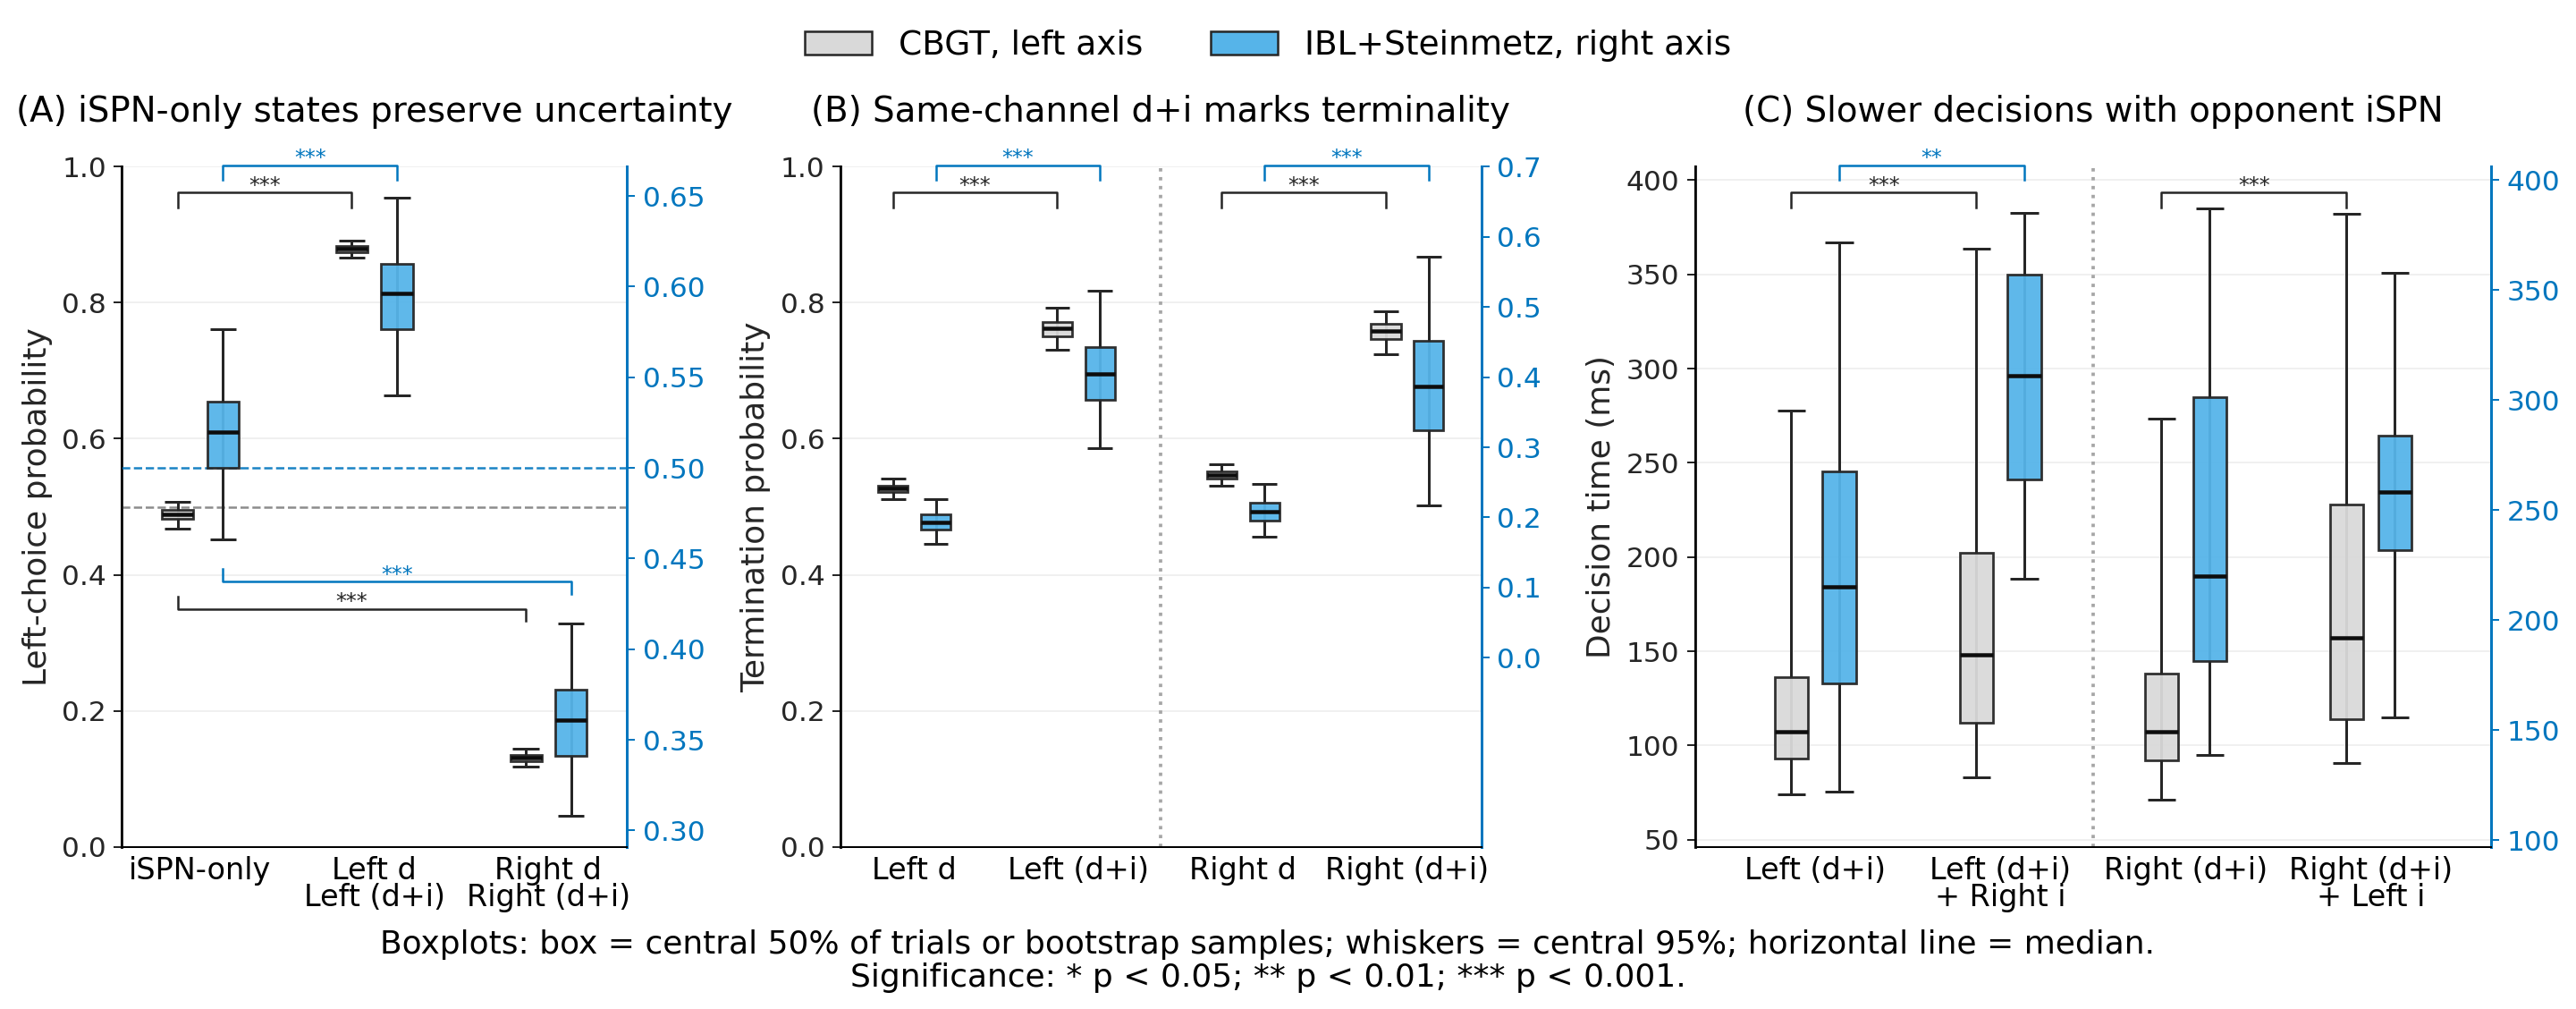

In [3]:
cbgt_main = read_csv(out_dir / "cbgt_prediction_main_results.csv")
empirical_main = read_csv(out_dir / "empirical_prediction_main_results.csv")
cbgt_raw = read_csv(out_dir / "cbgt_prediction_raw_decision_times.csv.gz")
empirical_raw = read_csv(out_dir / "empirical_prediction_raw_decision_times.csv.gz")
pairwise_tests = read_csv(out_dir / "prediction_significance_pairwise_tests.csv")

fig, plotted_percentiles = plot_prediction_boxplots_exact(
    cbgt_main,
    empirical_main,
    cbgt_raw,
    empirical_raw,
    pairwise_tests,
)

save_figure(fig, FIGURES / "main" / "Fig5_multiplexed_iSPN_roles")
write_csv(plotted_percentiles, out_dir / "fig5_plotted_percentiles.csv")
plt.show()